In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
data=pd.read_csv("raw_ethereum_wallet_dataset.csv")

In [3]:
data.head()

,Unnamed: 0,Index,Address,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,...,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,0,1,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,...,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,1,2,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,...,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,2,3,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,NaN,XENON
3,3,4,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,397555.90,25,9,0,...,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,4,5,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,382472.42,4598,20,1,...,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9841 entries, 0 to 9840
Data columns (total 51 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Unnamed: 0                                            9841 non-null   int64  
 1   Index                                                 9841 non-null   int64  
 2   Address                                               9841 non-null   str    
 3   FLAG                                                  9841 non-null   int64  
 4   Avg min between sent tnx                              9841 non-null   float64
 5   Avg min between received tnx                          9841 non-null   float64
 6   Time Diff between first and last (Mins)               9841 non-null   float64
 7   Sent tnx                                              9841 non-null   int64  
 8   Received Tnx                                          9841 non-null  

## Step 1: Cleaning, standardising, dealing with duplicates 

In [5]:
#drop useless columns
data.drop(['Unnamed: 0', 'Index'], axis=1, inplace=True)

In [6]:
#snake case
data.columns=(
    data.columns
    .str.lower()
    .str.replace(' ', '_')
    .str.replace(r"[()]", "", regex=True)
    .str.strip('_')
)

In [7]:
#are there repeating addresses
data["address"].value_counts().max()

np.int64(2)

In [8]:
#checking how many unique vs duplicate
data["address"].value_counts().value_counts()

count
1    9791
2      25
Name: count, dtype: int64

In [9]:
#checking variation in any column across its rows for each address
data.groupby("address").nunique().max(axis=1).value_counts()

1    9809
2       7
Name: count, dtype: int64

In [10]:
#how many different flag values each address has: 1->flag is consistent
data.groupby("address")["flag"].nunique().value_counts()

flag
1    9816
Name: count, dtype: int64

In [11]:
#dropping rows with duplicate addresses
data=data.drop_duplicates(subset="address")

In [12]:
#checking label imbalance
data.groupby('flag').size()

flag
0    7637
1    2179
dtype: int64

### Step 1 outcome:
Removed redundant columns, snake case columns, dealt with duplicate address rows by removing duplicates (possible beause all the column values for duplicate address rows are identical), acknowledged flag column imbalance.

## Step 2: Dealing with constant/near constant features

In [13]:
#identifying features
data.nunique()

address                                                9816
flag                                                      2
avg_min_between_sent_tnx                               5013
avg_min_between_received_tnx                           6223
time_diff_between_first_and_last_mins                  7810
sent_tnx                                                641
received_tnx                                            727
number_of_created_contracts                              20
unique_received_from_addresses                          256
unique_sent_to_addresses                                258
min_value_received                                     4589
max_value_received                                     6302
avg_val_received                                       6767
min_val_sent                                           4719
max_val_sent                                           6647
avg_val_sent                                           5854
min_value_sent_to_contract              

In [14]:
#dropping features that have zero variance 
data.drop(['erc20_avg_time_between_sent_tnx',
           'erc20_avg_time_between_rec_tnx',
           'erc20_avg_time_between_rec_2_tnx',
           'erc20_avg_time_between_contract_tnx',
           'erc20_min_val_sent_contract',
           'erc20_max_val_sent_contract',
           'erc20_avg_val_sent_contract'],
           axis=1, inplace=True)

In [15]:
#identifying near constant columns
def get_near_constant(data, threshold=0.995):
    near_const = []
    for col in data.columns:
        top_freq = data[col].value_counts(normalize=True, dropna=False).iloc[0]
        if top_freq >= threshold:
            near_const.append(col)
    return near_const

near_const_cols = get_near_constant(data)

In [16]:
near_const_cols

['min_value_sent_to_contract',
 'max_val_sent_to_contract',
 'avg_value_sent_to_contract',
 'total_ether_sent_contracts']

In [17]:
#assessing fraud signal in near-constant columns
# For each near-constant feature, compare fraud rates across its values.
# Signal score = max fraud rate - min fraud rate.
# A higher score means the feature separates fraudulent and non-fraudulent accounts better.

near_const_scores = {}

for col in near_const_cols:
    fraud_rates = data.groupby(col)["flag"].mean()
    signal_score = fraud_rates.max() - fraud_rates.min()
    near_const_scores[col] = signal_score

near_const_scores = pd.Series(near_const_scores).sort_values(ascending=False)

near_const_scores

max_val_sent_to_contract      0.222052
avg_value_sent_to_contract    0.222052
total_ether_sent_contracts    0.222052
min_value_sent_to_contract    0.222030
dtype: float64

In [18]:
drop_near_constant = near_const_scores[near_const_scores < 0.05].index.tolist()
keep_near_constant = near_const_scores[near_const_scores >= 0.05].index.tolist()

Near-constant features were not removed automatically. Because rare behaviours may be meaningful in fraud detection, each near-constant feature was assessed by comparing fraud rates across its values. Features with negligible signal were dropped, while features with meaningful fraud separation were transformed into binary indicators representing the presence of rare behaviour.

In [19]:
keep_near_constant

['max_val_sent_to_contract',
 'avg_value_sent_to_contract',
 'total_ether_sent_contracts',
 'min_value_sent_to_contract']

In [20]:
#all features proved to be useful, but all focus on the interaction with contract. So it was decided to convert to a single binary feature "sent_to_contract_flag"  
data["sent_to_contract_flag"] = (
    data[[
        'max_val_sent_to_contract',
        'avg_value_sent_to_contract',
        'total_ether_sent_contracts',
        'min_value_sent_to_contract'
    ]].sum(axis=1) > 0
).astype(int)

In [21]:
data.drop(['max_val_sent_to_contract',
            'avg_value_sent_to_contract',
            'total_ether_sent_contracts',
            'min_value_sent_to_contract'],
          axis=1, inplace=True)

In [22]:
#one more near constant variable
data['erc20_uniq_sent_addr.1'].value_counts()

erc20_uniq_sent_addr.1
0.0    8959
1.0      26
3.0       1
2.0       1
Name: count, dtype: int64

In [23]:
(data["erc20_uniq_sent_addr"] == data["erc20_uniq_sent_addr.1"]).all()

np.False_

In [24]:
#checking correlation
data[["erc20_uniq_sent_addr", "erc20_uniq_sent_addr.1"]].corr()

,erc20_uniq_sent_addr,erc20_uniq_sent_addr.1
erc20_uniq_sent_addr,1.000000,-0.002506
erc20_uniq_sent_addr.1,-0.002506,1.000000


In [25]:
#no correlation, random column, not in dataset description. decision:drop
data = data.drop(columns=["erc20_uniq_sent_addr.1"])

A duplicated column (erc20_uniq_sent_addr.1) was identified during preprocessing. Correlation analysis showed no relationship with the original feature and the variable was not described in the dataset documentation. It was therefore removed as a data artefact. The original feature, representing the number of unique ERC20 recipient addresses, was retained as a behavioural count variable and further transformed using log scaling and binary indicators.

### Step 2 outcome:
Dropped columns with zero variance (erc20 time and values to contracts columns). Checked columns with near zero variance (ether values send to contracts columns), decided to keep but convert to one binary flag sent_to_contract_flag and drop original columns. Found odd column erc20_uniq_sent_addr.1 assessed it to be random and dropped.

## Step 3: Missing values

In [26]:
na_counts = data.isna().sum().sort_values(ascending=False)

In [27]:
na_counts

erc20_most_sent_token_type                             2689
erc20_most_rec_token_type                               871
erc20_avg_val_rec                                       829
erc20_min_val_rec                                       829
erc20_total_ether_received                              829
erc20_total_ether_sent                                  829
erc20_total_ether_sent_contract                         829
erc20_uniq_sent_addr                                    829
erc20_uniq_rec_addr                                     829
erc20_uniq_rec_contract_addr                            829
total_erc20_tnxs                                        829
erc20_max_val_rec                                       829
erc20_min_val_sent                                      829
erc20_max_val_sent                                      829
erc20_avg_val_sent                                      829
erc20_uniq_sent_token_name                              829
erc20_uniq_rec_token_name               

In [28]:
#numeric ECR20 varibales
erc20_numeric_cols = [
    'erc20_avg_val_rec',
    'erc20_min_val_rec',
    'erc20_total_ether_received',
    'erc20_total_ether_sent',
    'erc20_total_ether_sent_contract',
    'erc20_uniq_sent_addr',
    'erc20_uniq_rec_addr',
    'erc20_uniq_rec_contract_addr',
    'total_erc20_tnxs',
    'erc20_max_val_rec',
    'erc20_min_val_sent',
    'erc20_max_val_sent',
    'erc20_avg_val_sent',
]

In [29]:
data[erc20_numeric_cols] = data[erc20_numeric_cols].fillna(0)

In [30]:
#categorical ECR20 varibles
data['erc20_most_sent_token_type'] = data['erc20_most_sent_token_type'].fillna("None")
data['erc20_most_rec_token_type'] = data['erc20_most_rec_token_type'].fillna("None")
data['erc20_uniq_sent_token_name'] = data['erc20_uniq_sent_token_name'].fillna("None")
data['erc20_uniq_rec_token_name'] = data['erc20_uniq_rec_token_name'].fillna("None")

In [31]:
#binary feature: erc20 activity flag 
data["has_erc20_activity_flag"] = (data["total_erc20_tnxs"] > 0).astype(int)

In [32]:
data.isna().sum()

address                                                0
flag                                                   0
avg_min_between_sent_tnx                               0
avg_min_between_received_tnx                           0
time_diff_between_first_and_last_mins                  0
sent_tnx                                               0
received_tnx                                           0
number_of_created_contracts                            0
unique_received_from_addresses                         0
unique_sent_to_addresses                               0
min_value_received                                     0
max_value_received                                     0
avg_val_received                                       0
min_val_sent                                           0
max_val_sent                                           0
avg_val_sent                                           0
total_transactions_including_tnx_to_create_contract    0
total_ether_sent               

### Step 3 outcome:
Missing values in ERC20-related features were not treated as random but as structural indicators of no ERC20 activity. Therefore, numeric variables were imputed with zero, while categorical variables were assigned a ‘None’ category. This preserves behavioural meaning and avoids distortion introduced by statistical imputation. A binary flag which indicates ERC20 activity created.

## Step 4: Feature engineering

### 1. Activity/ frequency features

In [33]:
#sent vs received transaction ratio (high ratio: receive -> send immediately)
#additive smoothing: adding 1 to denominator in case received_tnx=0
data["sent_received_ratio"] = data["sent_tnx"] / (data["received_tnx"] + 1)

In [34]:
#transaction intensity (burst behaviour)
data["tx_per_min"] = data["total_transactions_including_tnx_to_create_contract"] / (
    data["time_diff_between_first_and_last_mins"] + 1
)

### 2. Temporal features

In [35]:
#reaction speed ratio (measures how quickly an account reacts after receiving funds)
#ratio<1 -> sends faster than receives, ratio=1 send/recieve similar pace, ratio>1 accumulating behaviour
data["reaction_speed_ratio"] = data["avg_min_between_sent_tnx"] / (
    data["avg_min_between_received_tnx"] + 1
)

### 3. Value/ financial behaviour

In [36]:
#value flow ratio (are funds accumulated (high ratio) vs drained (low ratio)
data["value_sent_received_ratio"] = data["total_ether_sent"] / (
    data["total_ether_received"] + 1
)

In [37]:
#net flow
data["net_flow"] = data["total_ether_received"] - data["total_ether_sent"]

In [38]:
#the values like total_ether_sent are anticipated to be highly skewed so the next step is to 
data['total_ether_sent'].describe()
#so, due to strong right skew and extreme outliers, 
#logarithmic transformation is planned to be applied 
#to reduce the influence of large values and improve feature distribution.

count    9.816000e+03
mean     1.018513e+04
std      3.587784e+05
min      0.000000e+00
25%      2.259862e-01
50%      1.246589e+01
75%      1.009990e+02
max      2.858096e+07
Name: total_ether_sent, dtype: float64

In [39]:
#checking whether all columns i want to use log on are >-1
for col in [
    "total_ether_sent",
    "total_ether_received",
    "total_ether_balance",
    "avg_val_sent",
    "avg_val_received"
]:
    print(col, (data[col] <= -1).sum())
    

total_ether_sent 0
total_ether_received 0
total_ether_balance 761
avg_val_sent 0
avg_val_received 0


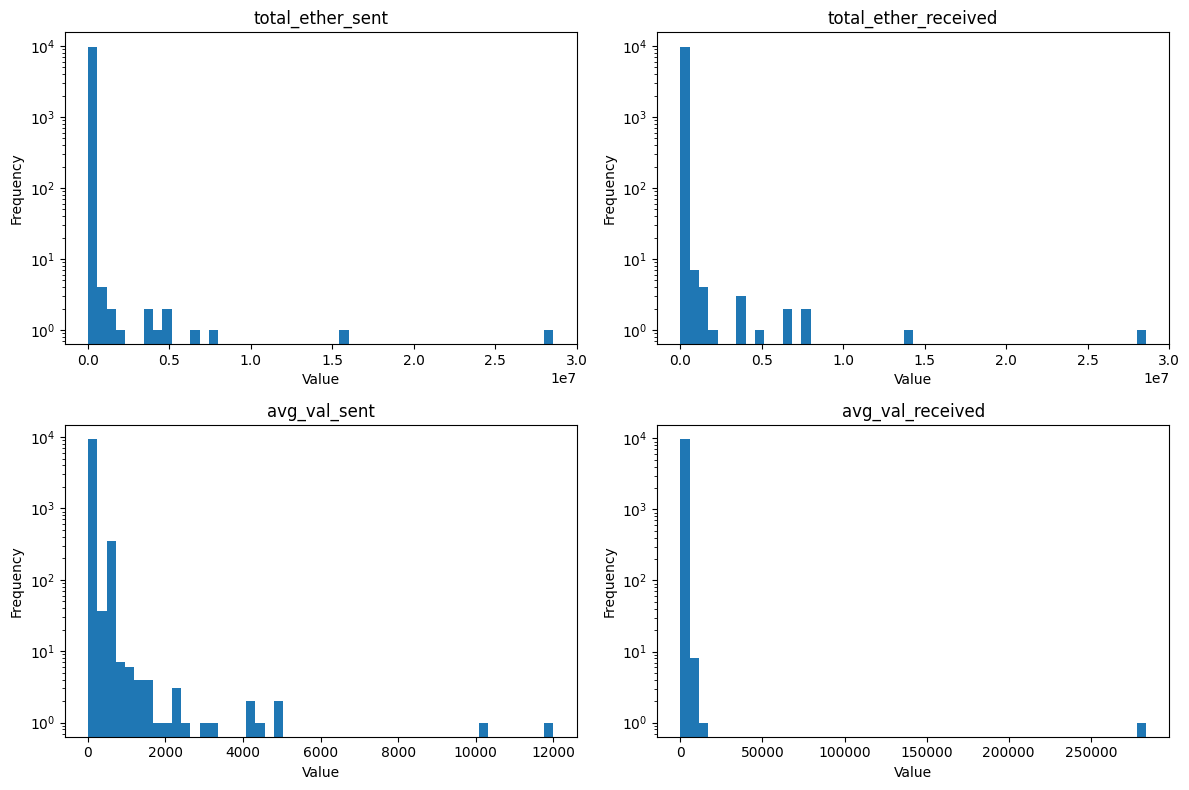

In [40]:
features = [
    "total_ether_sent",
    "total_ether_received",
    "avg_val_sent",
    "avg_val_received",
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), features):
    ax.hist(data[col], bins=50)
    ax.set_title(col)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
    
    #log scale is applied to the frequency axis to make low-frequency (rare) observations visible.
    #the data is highly right-skewed, so a linear scale would compress the tail and hide extreme values.
    ax.set_yscale("log")

plt.tight_layout()
plt.show()

In [41]:
#log stabilises extreme values
#non-negative value logs (log1p safely handles zeros)
data["log_total_ether_sent"] = np.log1p(data["total_ether_sent"])
data["log_total_ether_received"] = np.log1p(data["total_ether_received"])
data["log_avg_val_sent"] = np.log1p(data["avg_val_sent"])
data["log_avg_val_received"] = np.log1p(data["avg_val_received"])

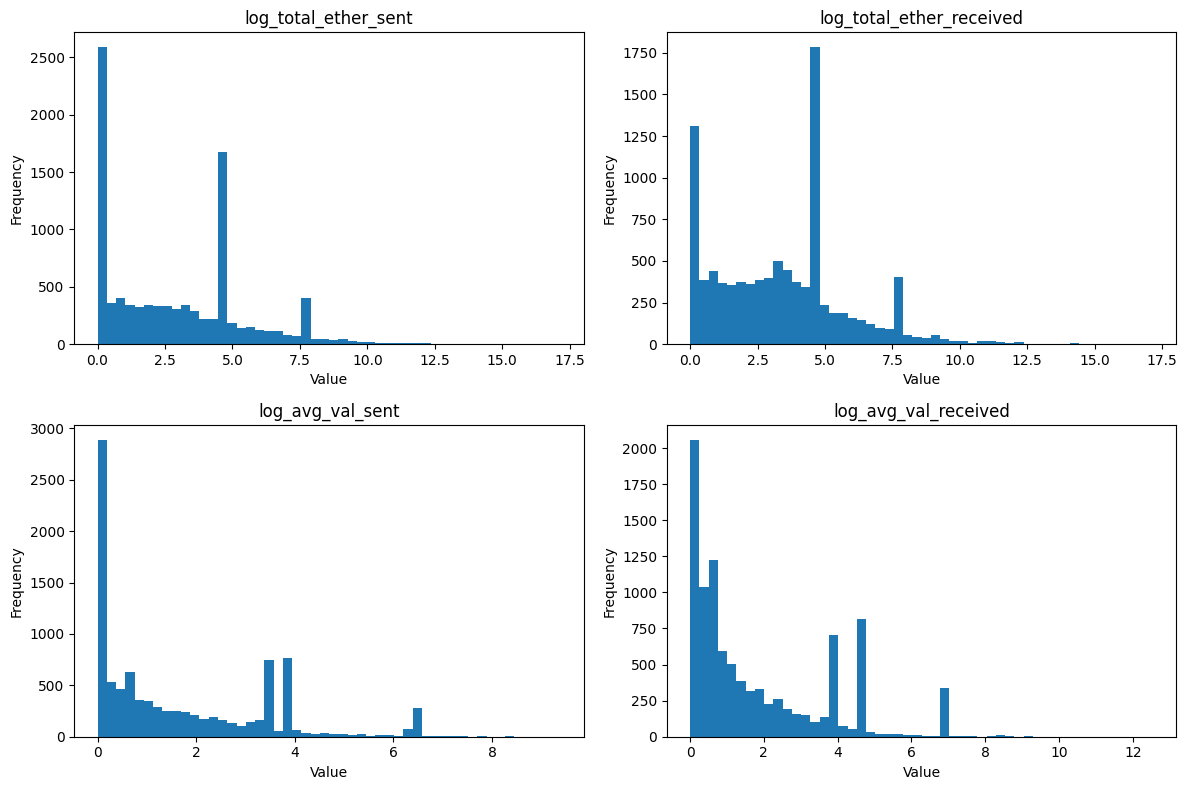

In [42]:
features = [
    "log_total_ether_sent",
    "log_total_ether_received",
    "log_avg_val_sent",
    "log_avg_val_received",
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), features):
    ax.hist(data[col], bins=50)
    ax.set_title(col)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()
#the log transform helped, but didn’t make the data perfectly symmetric

In [43]:
#skew before log tranfrom vs after table
features = [
    ("total_ether_sent", "log_total_ether_sent"),
    ("total_ether_received", "log_total_ether_received"),
    ("avg_val_sent", "log_avg_val_sent"),
    ("avg_val_received", "log_avg_val_received"),
]

rows = []

for raw, log in features:
    skew_before = data[raw].skew()
    skew_after = data[log].skew()
    
    reduction = ((skew_before - skew_after) / abs(skew_before)) * 100
    
    rows.append({
        "Feature": raw,
        "Skew (Before)": skew_before,
        "Skew (After)": skew_after,
        "% Reduction": reduction
    })

skew_table = pd.DataFrame(rows)
print(skew_table)

                Feature  Skew (Before)  Skew (After)  % Reduction
0      total_ether_sent      62.283966      0.762135    98.776354
1  total_ether_received      58.720554      0.668374    98.861771
2          avg_val_sent      25.559940      1.039087    95.934707
3      avg_val_received      96.394195      1.130714    98.826990


In [44]:
#balance treated separately because it has negative values
#balance_negative_flag: whether the account has negative balance
data["balance_negative_flag"] = (data["total_ether_balance"] < 0).astype(int)

#size/magnitude of the balance
data["log_abs_total_ether_balance"] = np.log1p(data["total_ether_balance"].abs())

In [45]:
#transaformimg max values into a meaningful range
# =1 -> transactions are consistent, >1 large spikes
data["sent_range_ratio"] = data["max_val_sent"] / (data["avg_val_sent"] + 1)
data["received_range_ratio"] = data["max_value_received"] / (data["avg_val_received"] + 1)

In [46]:
data.drop(
    [
        #have log copies already
        "total_ether_sent",
        "total_ether_received",
        "total_ether_balance",
        "avg_val_sent",
        "avg_val_received",
        #weak signal features
        "min_val_sent",
        "min_value_received",
        "max_val_sent", 
        "max_value_received" 
    ],
    axis=1,
    inplace=True,
)

### 4. Structural/ network behaviour

In [47]:
#outgoing address dispersion (how many different addresses are used per transaction?)
data["addr_dispersion_sent"] = data["unique_sent_to_addresses"] / (
    data["sent_tnx"] + 1
)


In [48]:
#incoming address dispersion
data["addr_dispersion_received"] = data["unique_received_from_addresses"] / (
    data["received_tnx"] + 1
)

In [49]:
data[[
    "addr_dispersion_sent",
    "addr_dispersion_received"
]].describe()

,addr_dispersion_sent,addr_dispersion_received
count,9816.000000,9816.000000
mean,0.390705,0.429075
std,0.301566,0.278805
min,0.000000,0.000000
25%,0.014068,0.142857
50%,0.500000,0.500000
75%,0.666667,0.666667
max,0.999216,0.999900


### 5. ERC20 Behaviour

ERC20-related features were highly sparse (many accounts have no ERC20 activity) and exhibited substantial redundancy across value-based variables. Therefore, these features were condensed into a smaller set capturing key behavioural dimensions, including activity presence, intensity, and proportional usage. In contrast, core ETH transaction features were retained in greater detail due to their broader coverage and complementary informational value

In [50]:
#ERC20 activity ratio (how much of the account’s activity is ERC20-based 
#relative to all transactions)
data["erc20_tx_ratio"] = data["total_erc20_tnxs"] / (
    data["total_transactions_including_tnx_to_create_contract"] + 1
)

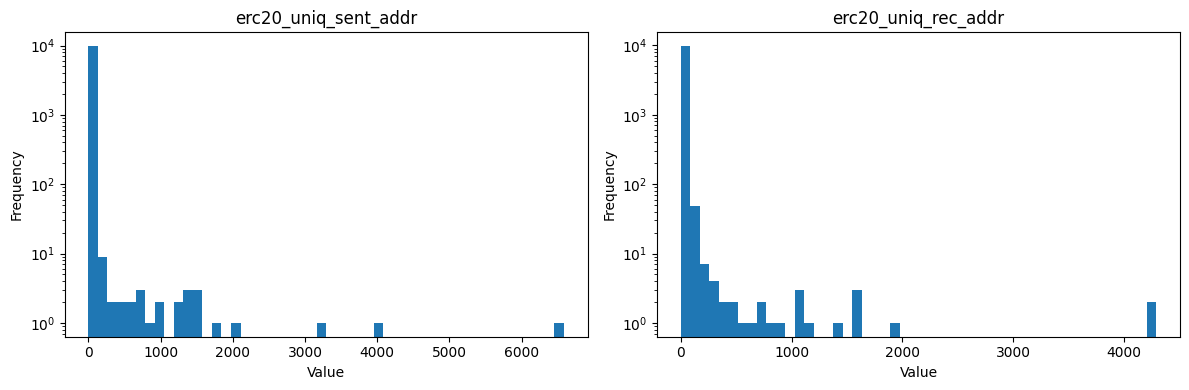

In [51]:
#erc20 unique address features
features = [
    "erc20_uniq_sent_addr",
    "erc20_uniq_rec_addr"
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, features):
    ax.hist(data[col], bins=50)
    ax.set_title(col)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
    
    ax.set_yscale("log")

plt.tight_layout()
plt.show()

Both ERC20 recipient and sender count features exhibit strong right skew and zero inflation, with the majority of observations concentrated at zero and a small number of extreme values forming a long right tail.

In [52]:
#creating acr20 sent binary flags (not doing same for erc20_rec_flag because very similar)
data["erc20_sent_flag"] = (data["erc20_uniq_sent_addr"] > 0).astype(int)

In [53]:
data["log_erc20_uniq_sent_addr"] = np.log1p(data["erc20_uniq_sent_addr"])
data["log_erc20_uniq_rec_addr"] = np.log1p(data["erc20_uniq_rec_addr"])

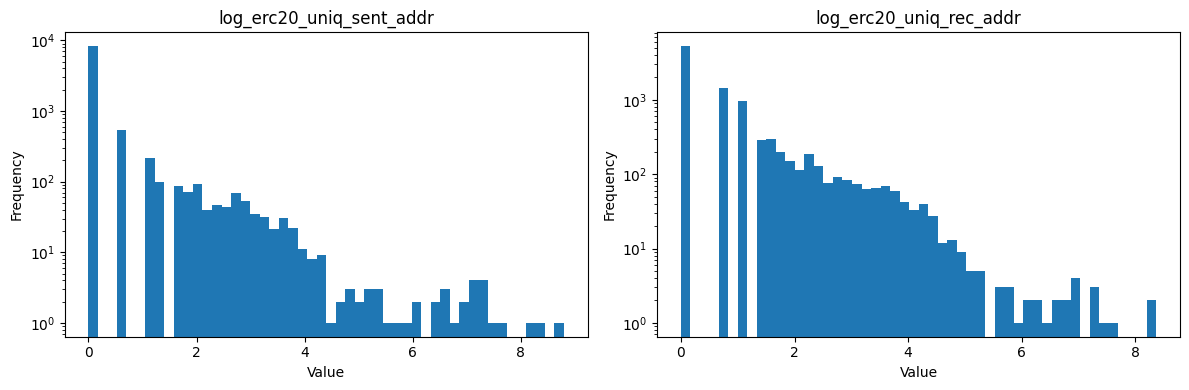

In [54]:
#erc20 unique address features
features = [
    "log_erc20_uniq_sent_addr",
    "log_erc20_uniq_rec_addr"
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, features):
    ax.hist(data[col], bins=50)
    ax.set_title(col)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
    
    ax.set_yscale("log")

plt.tight_layout()
plt.show()

In [55]:
#skew before log tranfrom vs after table
features = [
    ("erc20_uniq_sent_addr", "log_erc20_uniq_sent_addr"),
    ("erc20_uniq_rec_addr", "log_erc20_uniq_rec_addr"),
]

rows = []

for raw, log in features:
    skew_before = data[raw].skew()
    skew_after = data[log].skew()
    
    reduction = ((skew_before - skew_after) / abs(skew_before)) * 100
    
    rows.append({
        "Feature": raw,
        "Skew (Before)": skew_before,
        "Skew (After)": skew_after,
        "% Reduction": reduction
    })

skew_table = pd.DataFrame(rows)
print(skew_table)

                Feature  Skew (Before)  Skew (After)  % Reduction
0  erc20_uniq_sent_addr      42.420845      4.010283    90.546432
1   erc20_uniq_rec_addr      39.212195      1.843625    95.298339


In [56]:
#ERC20 network asymmetry (relationship between sent and received)
data["erc20_addr_balance_ratio"] = data["erc20_uniq_sent_addr"] / (
    data["erc20_uniq_rec_addr"] + 1
)

In [57]:
#converting from object to numeric
data["erc20_uniq_sent_token_name"] = pd.to_numeric(
    data["erc20_uniq_sent_token_name"], errors="coerce"
)

data["erc20_uniq_rec_token_name"] = pd.to_numeric(
    data["erc20_uniq_rec_token_name"], errors="coerce"
)

In [58]:
#after converting from object to numberic hidden missing values became aparent
#they essentially represent zero, so replaced by zeros
data["erc20_uniq_sent_token_name"] = data["erc20_uniq_sent_token_name"].fillna(0)
data["erc20_uniq_rec_token_name"] = data["erc20_uniq_rec_token_name"].fillna(0)

In [59]:
#number of different token types an account interacts with
#log transaform as before because skewed
data["log_erc20_unique_tokens_sent"] = np.log1p(data["erc20_uniq_sent_token_name"])
data["log_erc20_unique_tokens_rec"] = np.log1p(data["erc20_uniq_rec_token_name"])

In [60]:
data.info()

<class 'pandas.DataFrame'>
Index: 9816 entries, 0 to 9840
Data columns (total 52 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   address                                              9816 non-null   str    
 1   flag                                                 9816 non-null   int64  
 2   avg_min_between_sent_tnx                             9816 non-null   float64
 3   avg_min_between_received_tnx                         9816 non-null   float64
 4   time_diff_between_first_and_last_mins                9816 non-null   float64
 5   sent_tnx                                             9816 non-null   int64  
 6   received_tnx                                         9816 non-null   int64  
 7   number_of_created_contracts                          9816 non-null   int64  
 8   unique_received_from_addresses                       9816 non-null   int64  
 9   un

In [61]:
data.drop(
    [
        #REDUNDANT (overlap with other features)
        "erc20_total_ether_sent",
        "erc20_total_ether_received",
        "erc20_total_ether_sent_contract",
        "total_erc20_tnxs",

        # REDUNDANT VALUE STATISTICS
        "erc20_min_val_rec",
        "erc20_max_val_rec",
        "erc20_avg_val_rec",
        "erc20_min_val_sent",
        "erc20_max_val_sent",
        "erc20_avg_val_sent",

        #HAVE LOG VERSIONS
        "erc20_uniq_sent_addr",
        "erc20_uniq_rec_addr",
        "erc20_uniq_sent_token_name",
        "erc20_uniq_rec_token_name",
        "erc20_uniq_rec_contract_addr",

        #NOT USEFUL
        "erc20_most_sent_token_type",
        "erc20_most_rec_token_type",

    ],
    axis=1,
    inplace=True,
)

In [62]:
data.corr(numeric_only=True)

,flag,avg_min_between_sent_tnx,avg_min_between_received_tnx,time_diff_between_first_and_last_mins,sent_tnx,received_tnx,number_of_created_contracts,unique_received_from_addresses,unique_sent_to_addresses,total_transactions_including_tnx_to_create_contract,...,received_range_ratio,addr_dispersion_sent,addr_dispersion_received,erc20_tx_ratio,erc20_sent_flag,log_erc20_uniq_sent_addr,log_erc20_uniq_rec_addr,erc20_addr_balance_ratio,log_erc20_unique_tokens_sent,log_erc20_unique_tokens_rec
flag,1.000000,-0.029619,-0.118640,-0.269612,-0.078190,-0.079536,-0.013752,-0.032066,-0.045692,-0.100551,...,-0.028426,-0.074943,0.174014,0.044230,-0.125581,-0.122575,-0.051344,-0.007003,-0.098687,-0.051470
avg_min_between_sent_tnx,-0.029619,1.000000,0.061060,0.214174,-0.032270,-0.035728,-0.006185,-0.015915,-0.017679,-0.043571,...,-0.010968,0.128829,0.059052,0.083078,0.132311,0.052213,0.161496,-0.002026,0.064066,0.177774
avg_min_between_received_tnx,-0.118640,0.061060,1.000000,0.303425,-0.040432,-0.053515,-0.008385,-0.029600,-0.025755,-0.060745,...,-0.017007,-0.005670,0.117121,0.020627,0.063193,0.011410,0.015619,-0.003636,0.020241,0.021055
time_diff_between_first_and_last_mins,-0.269612,0.214174,0.303425,1.000000,0.154573,0.148568,-0.003875,0.037079,0.071156,0.189499,...,0.024587,-0.206433,-0.313975,0.070158,0.434567,0.421950,0.543323,-0.002331,0.434824,0.561498
sent_tnx,-0.078190,-0.032270,-0.040432,0.154573,1.000000,0.198423,0.320611,0.130034,0.670000,0.731488,...,0.051551,-0.086983,-0.092200,-0.004077,0.147836,0.255291,0.269408,0.132699,0.120366,0.206634
received_tnx,-0.079536,-0.035728,-0.053515,0.148568,0.198423,1.000000,-0.003847,0.648651,0.164092,0.806387,...,0.414535,-0.141355,-0.153795,-0.019714,0.106848,0.074773,0.232694,-0.001272,0.058780,0.219705
number_of_created_contracts,-0.013752,-0.006185,-0.008385,-0.003875,0.320611,-0.003847,1.000000,-0.002217,0.084595,0.281431,...,-0.001054,-0.026438,-0.014120,0.002481,0.032306,0.118778,0.101069,0.000308,0.020382,0.040237
unique_received_from_addresses,-0.032066,-0.015915,-0.029600,0.037079,0.130034,0.648651,-0.002217,1.000000,0.159811,0.523835,...,0.346545,-0.050485,0.034838,-0.010584,0.082169,0.084300,0.151971,0.000187,0.062521,0.138823
unique_sent_to_addresses,-0.045692,-0.017679,-0.025755,0.071156,0.670000,0.164092,0.084595,0.159811,1.000000,0.498147,...,0.058408,0.047979,-0.038257,-0.003478,0.109603,0.163616,0.199612,-0.000075,0.112849,0.176110
total_transactions_including_tnx_to_create_contract,-0.100551,-0.043571,-0.060745,0.189499,0.731488,0.806387,0.281431,0.523835,0.498147,1.000000,...,0.317141,-0.149807,-0.160095,-0.015738,0.160487,0.207383,0.323299,0.073447,0.110419,0.272752


## Step 5: Saving the processed data

In [63]:
data.to_parquet("processed_wallet_fraud_dataset.parquet", index=False)

Following transformation, the dataset was persisted in Parquet format to preserve data types and improve I/O efficiency for subsequent modelling workflows.